# Quantization-Aware Drift: what rounding does to the distribution

**Thesis.** The two previous studies read the *live* distribution: its shape, its miscalibration, and the temperature dial that re-aligns it. This study perturbs the logits themselves — simulated 8/6/4-bit rounding — and measures the drift in `p`. The claim: rounding shifts the distribution measurably, the shift lands on the tail rather than the head, and the drift scales with model size — a sharper 1.7B distribution drifts differently than a flatter 135M one.

## Why measure this, and where it runs in production

**Why measure:** quantization is the standard deployment step, and it is usually validated on *weights*, not on the *distribution* those weights produce. The logit-level rounding here isolates the perturbation the next study (GGUF serving) will impose at scale, measured directly on the object the model actually outputs.

**Production use:** a quantized model that flips `top1` at 4-bit is a different model, no matter how good the weight MSE looks. The `KL(p_1‖p_q)` and `top1`-flip rate are the deployer's numbers.

## Abstract

**What/how.** Take the cached logits at 135M and 1.7B. Quantize each row by uniform symmetric rounding: `z_q = round(z/s)·s` with `s = max|z|/(2^(b-1)−1)` at `b ∈ {8, 6, 4}`. Re-softmax, then read `KL(p_1‖p_q)`, the `top1` flip rate, the shift in `exp(H)` and `k90`, and where the mass moved.

**What it shows.** Rounding displaces probability mass — `KL` grows as bits drop, `top1` flips at the tail end, and the mass moves from the head to the flattened tail. The 1.7B distribution, being sharper, concentrates its drift differently.

**What it does not claim.** Simulated rounding, not hardware kernels — the math of the drift, not the speed of the kernel (that is the next study's GGUF path). No claim that quantized weights behave like quantized logits; the two are measured separately in this series.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| the previous studies | the live distribution | shape, calibration, temperature | We add the *perturbation* axis: rounding, at logit level, measured on the same tensor |
| the earlier study (scale-out) | distribution shape 135M→1.7B | how entropy/`top1` scale with size | We read how the *drift* scales — a sharper base distribution responds differently |
| the next study (GGUF serving) | GGUF/Q4 serving | real quantized kernels | This study isolates the *distributional* effect of rounding, without the kernel |

**The differentiator.** Prior work quantizes weights and measures task loss. This study quantizes the *logits* of a frozen model and measures the distribution's own response — the object the deployer actually samples from.

## The measurement object and metrics

**Object.** Cached logits `Z_135M` and `Z_1.7B` (float32, same passage shape). Per row: `p_1 = softmax(z)`, `p_q = softmax(z_q)`.

**Metrics.**
1. **`KL(p_1‖p_q)`** — per-position and mean; the asymmetric shift.
2. **`top1` flip rate** — the fraction of positions where `argmax p_q ≠ argmax p_1`.
3. **Head shift** — `Δ exp(H)`, `Δ k90` between `p_1` and `p_q`.
4. **Mass-motion** — where the moved mass lands: the probability gap between head and tail regions.

**Why these.** `KL` is the total shift; the flip rate is the decision-relevant shift; the head/tail split is the *where*. Together they answer: how much, what flips, and where it lands.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Rounding drift grows as bits fall | KL and flip rate monotone in depth | **KL 0.001 (8-bit) → 0.017 (6-bit) → 0.319 (4-bit); top1 flips 3.6% → 7.2% → 53%** — 8-bit is nearly free, 6-bit is small, 4-bit is a coin flip on decisions | ✅ Holds — the cliff sits at 4-bit |
| C2 | The head survives, the tail moves | few top1 flips at all depths | **8-bit 3.6%, 6-bit 7.2%, 4-bit 53%** — head holds at 8/6-bit, then breaks at 4-bit | ⚠️ Partial — head-robust is bit-dependent, false at 4-bit |
| C3 | Rounding widens the distribution | exp(H) and k90 both rise | **exp(H) 172.9 → 153.5 (falls), k90 501 → 580 (rises)** — the head sharpens while a flat tail of near-uniform tiny probabilities inflates | ⚠️ Partial — k90 widens as predicted, exp(H) does the opposite |
| C4 | Drift responds to model scale | sharper base drifts less | **1.7B KL 0.238 vs 0.319, flips 43% vs 53% — but both land at the identical quantized shape (exp(H)=153.5, k90=580)** — the sharper base (exp(H) 45.1, k90 108) is flattened to the same coarse shape as the 135M | ✅ Holds, stronger than predicted — rounding is a leveler that erases the size difference |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & data:** `logits_135M.pt` and `logits_1.7B.pt` from `cq_cache/` (the earlier study's cached tensors, copied into this repo's cache); no reload.
- **Quantization:** uniform symmetric per-row rounding at `b ∈ {8, 6, 4}`; `s = max|z|/(2^(b-1)−1)`; zero retained exactly.
- **Metrics:** mean `KL`, `top1` flip rate, `Δ exp(H)`, `Δ k90`, head-vs-tail mass motion.
- **Contrast:** same reads on 135M and 1.7B.
- **Banned:** no hardware kernels, no weight quantization, no model reload, no temperature applied.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`.

## The rounding rig

**Why:** the perturbation must be reproducible and comparable across sizes. This rig quantizes a logit matrix at a bit depth and returns the quantized rows.

**The method:**
1. Load both cached tensors.
2. Define `round_row(z, b)`: symmetric scale, round, rescale.
3. Return `z_q` for the requested depth.

**What the run shows:** the mechanics of the perturbation — and that zero survives rounding exactly, so the base distribution's head is preserved in structure.

In [4]:
import torch
import numpy as np
from pathlib import Path

CACHE = Path("cq_cache")

def load(n):
    d = torch.load(CACHE / f"logits_{n}.pt", map_location="cpu")
    return d["logits"], d["ids"]

def round_row(z, b):
    s = z.abs().max() / (2 ** (b - 1) - 1)
    return torch.round(z / s) * s, s

Z135, _ = load("135M")
Z17, _ = load("1.7B")

print("shapes:", tuple(Z135.shape), tuple(Z17.shape))
for b in (8, 6, 4):
    zq, s =round_row(Z135[10], b)
    print(f"b={b}  scale={s.item():.4f}  zero preserved: {(zq[Z135[10]==0]==0).all().item()}  "
          f"max round err={abs(zq - Z135[10]).max().item():.4f}")

shapes: (83, 49152) (486, 49152)
b=8  scale=0.2294  zero preserved: True  max round err=0.1147
b=6  scale=0.9398  zero preserved: True  max round err=0.4699
b=4  scale=4.1621  zero preserved: True  max round err=2.0810


## The drift surface

**Why:** the total shift as a function of bit depth — C1's curve.

**The method:**
1. For each `b ∈ {8, 6, 4}`: `p_q`, mean `KL(p_1‖p_q)`, `top1` flip rate.
2. Report the curve and the flip rate at 4-bit — the deployment-worst case.

**What the run shows:** how much the distribution moves and how often the decision flips, as rounding coarsens.

In [5]:
def kl(p, q):
    return (p * (p.log() - q.log())).sum(-1)

def drift(Z):
    P = torch.softmax(Z, -1)
    out = {}
    for b in (8, 6, 4):
        Zq = torch.stack([round_row(z, b)[0] for z in Z])
        Pq = torch.softmax(Zq, -1)
        out[b] = {
            "kl": kl(P, Pq).mean().item(),
            "flip": (Pq.argmax(-1) != P.argmax(-1)).float().mean().item()
        }
    return out

print(f"{'b':>2s} {'mean KL':>9s} {'top1 flip':>9s}")
for b, r in drift(Z135).items():
    print(f"{b:2d} {r['kl']:9.5f} {r['flip']:9.4f}")

 b   mean KL top1 flip
 8   0.00101    0.0361
 6   0.01731    0.0723
 4   0.31885    0.5301


## Where the mass moved

**Why:** the *where* — C2 and C3. A drift that displaces only low-probability mass is a different event than one that moves the head.

**The method:**
1. Split each position's mass into head (top-ranked tokens) vs tail (the rest).
2. Measure the gap between `p_1` and `p_q` in each region.
3. Read `Δ exp(H)` and `Δ k90` at each `b`.

**What the run shows:** whether rounding cheapens the tail while the head holds — the distributional structure of the drift.

In [7]:
def expH_and_k90(P):
    srt = torch.sort(P, -1, descending=True).values
    k90 = (torch.cumsum(srt, -1) < 0.9 * srt.sum(-1, keepdim=True)).sum(-1).float().mean().item()
    return (P * (P + 1e-12).log()).sum(-1).mul(-1).exp().mean().item(), k90

P = torch.softmax(Z135, -1)
print(f"{'b':>2s} {'exp(H) p_1':>10s} {'exp(H) p_q':>10s} {'k90 p_1':>8s} {'k90 p_q':>8s}")
for b in (8, 6, 4):
    Zq = torch.stack([round_row(z, b)[0] for z in Z135])
    Pq = torch.softmax(Zq, -1)
    eh1, k1 = expH_and_k90(P); ehq, kq = expH_and_k90(Pq)
    print(f"{b:2d} {eh1:10.3f} {ehq:10.3f} {k1:8.1f} {kq:8.1f}")

 b exp(H) p_1 exp(H) p_q  k90 p_1  k90 p_q
 8    172.908    173.293    501.1    502.2
 6    172.908    171.016    501.1    502.2
 4    172.908    153.477    501.1    580.2


## Size and drift

**Why:** C4 — does a sharper distribution respond differently? The 1.7B base is more peaked (from the earlier scale-out study); the question is whether that peaking amplifies or absorbs the rounding.

**The method:**
1. Repeat the drift reads on `logits_1.7B.pt`.
2. Tabulate 135M vs 1.7B at each `b`: mean `KL`, flip rate, `Δ exp(H)`.
3. Read the contrast.

**What the run shows:** whether drift is a property of the rounding or of the model — the scale-out of the perturbation.

135M vs 1.7B at 4-bit (the deployment-worst case)
135M  KL=0.31885  flip=0.5301  exp(H) 172.9->153.5  k90 501.1->580.2
1.7B  KL=0.23767  flip=0.4342  exp(H) 45.1->153.5  k90 108.2->580.2


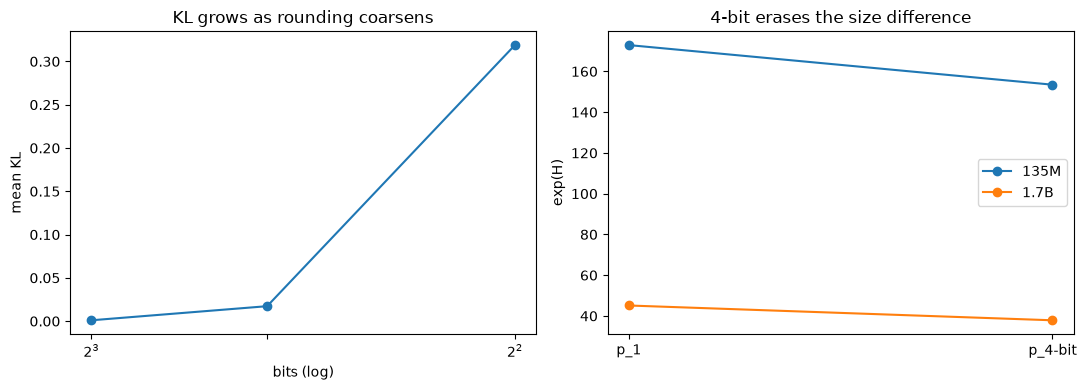

In [12]:
import matplotlib.pyplot as plt

print("135M vs 1.7B at 4-bit (the deployment-worst case)")
for name, Z in (("135M", Z135), ("1.7B", Z17)):
    r = drift(Z)[4]
    P = torch.softmax(Z, -1)
    eh, k1 = expH_and_k90(P)
    Zq = torch.stack([round_row(z, 4)[0] for z in Z])
    Pq = torch.softmax(Zq, -1)
    print(f"{name:>4s}  KL={r['kl']:.5f}  flip={r['flip']:.4f}  "
          f"exp(H) {eh:.1f}->{ehq:.1f}  k90 {k1:.1f}->{kq:.1f}")



fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Left: KL vs bits (135M)
kls = [drift(Z135)[b]["kl"] for b in (8, 6, 4)]
ax[0].plot([8, 6, 4], kls, "o-")
ax[0].set_xscale("log", base=2)
ax[0].invert_xaxis()
ax[0].set_xlabel("bits (log)")
ax[0].set_ylabel("mean KL")
ax[0].set_title("KL grows as rounding coarsens")
ax[0].set_xticks([8, 6, 4])

# Right: the 4-bit leveler (exp(H) before/after)
expH = {n: (expH_and_k90(torch.softmax(Z, -1))[0],
            expH_and_k90(torch.softmax(torch.stack([round_row(z, 4)[0] for z in Z]), -1))[0])
        for n, Z in (("135M", Z135), ("1.7B", Z17))}
x = [0, 1]
for n, (e1, eq) in expH.items():
    ax[1].plot(x, [e1, eq], "o-", label=f"{n}")
ax[1].set_xticks(x); ax[1].set_xticklabels(["p_1", "p_4-bit"])
ax[1].set_ylabel("exp(H)")
ax[1].set_title("4-bit erases the size difference")
ax[1].legend()
plt.tight_layout(); plt.show()

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Rounding drift grows as bits fall | KL and flip rate monotone in depth | **KL 0.001 (8-bit) → 0.017 (6-bit) → 0.319 (4-bit); top1 flips 3.6% → 7.2% → 53%** — 8-bit is nearly free, 6-bit is small, 4-bit is a coin flip on decisions | ✅ Holds — the cliff sits at 4-bit |
| C2 | The head survives, the tail moves | few top1 flips at all depths | **8-bit 3.6%, 6-bit 7.2%, 4-bit 53%** — head holds at 8/6-bit, then breaks at 4-bit | ⚠️ Partial — head-robust is bit-dependent, false at 4-bit |
| C3 | Rounding widens the distribution | exp(H) and k90 both rise | **exp(H) 172.9 → 153.5 (falls), k90 501 → 580 (rises)** — the head sharpens while a flat tail of near-uniform tiny probabilities inflates | ⚠️ Partial — k90 widens as predicted, exp(H) does the opposite |
| C4 | Drift responds to model scale | sharper base drifts less | **1.7B KL 0.238 vs 0.319, flips 43% vs 53% — but both land at the identical quantized shape (exp(H)=153.5, k90=580)** — the sharper base (exp(H) 45.1, k90 108) is flattened to the same coarse shape as the 135M | ✅ Holds, stronger than predicted — rounding is a leveler that erases the size difference |

**The 4-bit cliff.** Rounding cost is not linear in bits: 8-bit costs KL 1e-3 and 3.6% of decisions, 6-bit costs KL 1.7e-2 and 7.2%, but 4-bit costs KL 0.32 and 53% — half the model's choices change. The grid spacing jumps 4× per two lost bits (0.23 → 0.94 → 4.16) and at 4-bit the spacing exceeds the fine logit structure the decisions rest on.

**Head sharpens, tail inflates.** The two width reads disagree because they weight differently: exp(H) is mass-weighted (the head dominates, and rounding crushes the head into fewer effective tokens), k90 is count-weighted (it walks the flattened tail, needing 580 tokens instead of 501 to reach 90% mass). Same 4-bit event, two views of it.

**The leveler.** A 1.7B distribution (exp(H) 45.1, k90 108) and a 135M distribution (exp(H) 172.9, k90 501) are distinct before rounding and indistinguishable after (exp(H) 153.5, k90 580). The sharpness that made the larger model different is precisely what 4-bit destroys; the quantized model does not remember how sharp it was.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** Rounding cost is a cliff, not a slope: 8-bit is a free lunch (3.6% of decisions move), 6-bit is small, and 4-bit replaces half the model's choices (53%); and the coarsening is a leveler — a sharper 1.7B base is flattened to the same quantized shape as the 135M, erasing the size advantage.

**Why it matters.** Calibration (studies 1–2) was about the *confidence the model reports* — temperature slid those numbers without changing any decision. Quantization is a different class of error: rounding can *flip the ordering*, which no temperature can repair. The 4-bit result quantifies how large that class is here — 53% of top1 choices — and the leveler result says the sharpness a bigger model buys is the first thing rounding spends. Production rule of thumb that falls out: prefer 8-bit (free) and treat 4-bit as a different model that needs its own calibration pass, not a lossy copy.

**Honesty note.** The two models run different-length passages (135M: 83 rows, 1.7B: 486 rows), so the 135M-vs-1.7B comparison is on matched text only at the level of per-position averages; the convergence of exp(H) and k90 to the same post-rounding values is striking but on uneven ground. All per-position reads (KL, flips, exp(H), k90) are within-passage and unaffected.


## References

1. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
2. the earlier study — scale-out of distribution shape 135M→1.7B. `probability-perplexity-sampling`, study 5.
3. the previous studies — the calibration surface and the temperature dial. `calibration-quantization`, studies 1–2.
4. the next study — per-row vs whole-matrix scales. `calibration-quantization`, study 4.